In [1]:
from pathlib import Path
import sys
import random
import copy
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, average_precision_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from DataProcessing import Dataprocessing, Sensors, Actuators, NPI_ATTACK_IDS
from ModelTraining import LSTMAutoencoder, train_one_epoch, evaluate_reconstruction_loss
print(f"Using preprocessing module: {Dataprocessing.__module__}")
print(f"Sensor features: {len(Sensors)}")
print(f"Actuator features: {len(Actuators)}")
print(f"NPI attacks excluded from dynamic recovery: {sorted(NPI_ATTACK_IDS)}")

import warnings
warnings.filterwarnings('ignore')

device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print("device:", device)

Using preprocessing module: DataProcessing
Sensor features: 25
Actuator features: 26
NPI attacks excluded from dynamic recovery: [5, 9, 12, 15, 18]
device: cuda


In [2]:
SEQ_LEN = 64
STRIDE = 5
INPUT_DIM = 51

BATCH_SIZE = 512
EPOCHS = 100
PATIENCE = 8
RANDOM_SEED = 42

# MinMax
BEST_PARAMS = {
    "score_mode": "max",
    "conv_channels": 64,
    "kernel_size": 3,
    "hidden_size": 64,
    "num_layers": 4,
    "dropout": 0.49521204489910164,
    "bidirectional": True,
    "learning_rate": 0.0002654334209893315,
    "weight_decay": 5.414328125404531e-05,
    "threshold_percentile": 96.87360466212871,
    "top_k": 5,
}

# WhitenedPCA-Maha (new method)
WPCA_N    = 22
WPCA_SF   = 0.925
WPCA_PCT  = 99.2

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_global_seed(RANDOM_SEED)

In [3]:
start_time = pd.to_datetime("2015-12-23 12:00:00")

X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, metadata = Dataprocessing(
    start_time=start_time,
    SEQ_LEN=SEQ_LEN,
    STRIDE=STRIDE,
    return_metadata=True,
    # dataset_dir=DATASET_DIR,
    sensor_alpha=0.1,
    baseline_k=3.0,
    sensor_recovery_ratio=0.8,
    recovery_hold_windows=5,
)

# numpy -> tensor，並塑形
train_dataset = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(np.zeros(len(X_train_seq), dtype=np.int64)))
val_dataset = TensorDataset(torch.from_numpy(X_val_seq), torch.from_numpy(np.zeros(len(X_val_seq), dtype=np.int64)))
test_dataset = TensorDataset(torch.from_numpy(X_test_seq), torch.from_numpy(y_test_seq))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

attack_window_df = metadata["attack_window_df"].copy()
recovery_segments = metadata["recovery_segments"].copy()

# display(recovery_segments[[
#     "attack_id", "attack_name", "start", "end", "recovery_end",
#     "recovery_seconds", "key_sensors", "critical_actuators",
#     "used_for_dynamic_label",
# ]].head())



------------------------- Original Data -------------------------
Normal Data = (495000, 63)
Attack Data = (449919, 63)

------------------------- Processing ... -------------------------
Normal data = (424800, 63)
Skip data = 70200
Number of total data = (874719, 62)
train_set = (339840, 63)
val_set = (42480, 63)
test_set = (492399, 63)
Test data has 438514 normal data and 53885 abnomaly data.
train gaps: 0
val gaps: 0
test gaps: 1
sensor features (25): ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601']
actuator features (26): ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'P401', 'P402', 'P403', 'P404', 'UV401', 'P501', 'P502', 'P601', 'P602', 'P603']

------------------------- Recovery-aware Labels

#### LSTMAE


In [4]:
history = {"train_loss": [], "val_loss": []}

def compute_window_score(reconstruction, batch_x, mode="mean", top_k=5):
    point_error = (reconstruction - batch_x) ** 2
    timestep_error = point_error.mean(dim=2)

    if mode == "mean":
        return timestep_error.mean(dim=1)
    if mode == "max":
        return timestep_error.max(dim=1).values
    if mode == "topk":
        k = min(top_k, timestep_error.shape[1])
        topk_vals = torch.topk(timestep_error, k=k, dim=1).values
        return topk_vals.mean(dim=1)

    raise ValueError(f"Unsupported mode: {mode}")


def get_reconstruction_errors(model, data_array: np.ndarray, device, batch_size: int = 512, score_mode: str = "topk", top_k: int = 7):
    model.eval()
    scores = []
    dataset = TensorDataset(torch.from_numpy(data_array).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            reconstruction = model(batch_x)
            batch_error = compute_window_score(reconstruction, batch_x, mode=score_mode, top_k=top_k)
            scores.append(batch_error.detach().cpu().numpy())

    return np.concatenate(scores)


def fit_model(params, capture_history=False):
    seed = int(params.get("seed", RANDOM_SEED))
    set_global_seed(seed)

    model = LSTMAutoencoder(
        input_dim=INPUT_DIM,
        conv_channels=params["conv_channels"],
        kernel_size=params["kernel_size"],
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        bidirectional=params["bidirectional"],
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

    local_history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state_dict = None
    wait = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_reconstruction_loss(model, val_loader, criterion, device)

        if capture_history:
            local_history["train_loss"].append(train_loss)
            local_history["val_loss"].append(val_loss)

        print(f"Epoch [{epoch:02d}/{EPOCHS}] train_loss={train_loss:.6f} val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state_dict)
    print(model)
    return model, best_val_loss, local_history


def compute_binary_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }



In [5]:
best_params = dict(BEST_PARAMS)
best_params["seed"] = RANDOM_SEED

print("Fixed best params from Optuna AttackGroupCV study")
print(best_params)

Fixed best params from Optuna AttackGroupCV study
{'score_mode': 'max', 'conv_channels': 64, 'kernel_size': 3, 'hidden_size': 64, 'num_layers': 4, 'dropout': 0.49521204489910164, 'bidirectional': True, 'learning_rate': 0.0002654334209893315, 'weight_decay': 5.414328125404531e-05, 'threshold_percentile': 96.87360466212871, 'top_k': 5, 'seed': 42}


In [6]:
best_params = dict(BEST_PARAMS)
best_params["seed"] = RANDOM_SEED

best_model, best_val_loss, history = fit_model(best_params, capture_history=True)

threshold_errors = get_reconstruction_errors(
    best_model,
    X_val_seq,
    device,
    batch_size=BATCH_SIZE,
    score_mode=best_params["score_mode"],
    top_k=best_params["top_k"],
)

threshold = np.percentile(threshold_errors, best_params["threshold_percentile"])

attack_errors = get_reconstruction_errors(
    best_model,
    X_test_seq,
    device,
    batch_size=BATCH_SIZE,
    score_mode=best_params["score_mode"],
    top_k=best_params["top_k"],
)

y_true = attack_window_df["label"].to_numpy(dtype=np.int64)
y_pred = (attack_errors > threshold).astype(np.int64)

evaluation_df = attack_window_df.copy()
evaluation_df["error"] = attack_errors
evaluation_df["threshold"] = threshold
evaluation_df["y_pred"] = y_pred

print(f"Best val loss: {best_val_loss:.6f}")
print(f"Threshold percentile: {best_params['threshold_percentile']:.4f}")
print(f"Threshold: {threshold:.6f}")
print(f"Official F1: {f1_score(y_true, y_pred, zero_division=0):.4f}")

Epoch [01/100] train_loss=0.128001 val_loss=0.048574
Epoch [02/100] train_loss=0.039481 val_loss=0.048560
Epoch [03/100] train_loss=0.038749 val_loss=0.047706
Epoch [04/100] train_loss=0.037714 val_loss=0.044355
Epoch [05/100] train_loss=0.027257 val_loss=0.035729
Epoch [06/100] train_loss=0.020061 val_loss=0.029952
Epoch [07/100] train_loss=0.017412 val_loss=0.021715
Epoch [08/100] train_loss=0.013210 val_loss=0.016032
Epoch [09/100] train_loss=0.009860 val_loss=0.013076
Epoch [10/100] train_loss=0.008826 val_loss=0.011681
Epoch [11/100] train_loss=0.007887 val_loss=0.010341
Epoch [12/100] train_loss=0.007331 val_loss=0.009076
Epoch [13/100] train_loss=0.007045 val_loss=0.011500
Epoch [14/100] train_loss=0.006941 val_loss=0.007897
Epoch [15/100] train_loss=0.006523 val_loss=0.007966
Epoch [16/100] train_loss=0.006407 val_loss=0.006827
Epoch [17/100] train_loss=0.006264 val_loss=0.006557
Epoch [18/100] train_loss=0.006184 val_loss=0.006626
Epoch [19/100] train_loss=0.005964 val_loss=0.

In [7]:
y_true = attack_window_df["label"].to_numpy(dtype=np.int64)
y_pred = (attack_errors > threshold).astype(np.int64)

evaluation_df = attack_window_df.copy()
evaluation_df["error"] = attack_errors
evaluation_df["threshold"] = threshold
evaluation_df["y_pred"] = y_pred

print(f"Best val loss: {best_val_loss:.6f}")
print(f"Threshold percentile: {best_params['threshold_percentile']:.4f}")
print(f"Threshold: {threshold:.6f}")
print(f"Official F1: {f1_score(y_true, y_pred, zero_division=0):.4f}")

Best val loss: 0.004816
Threshold percentile: 96.8736
Threshold: 0.037160
Official F1: 0.2623


In [8]:
def build_ignore_mask(eval_df, ignore_col=None):

    if ignore_col is None:
        return np.ones(len(eval_df), dtype=bool)

    if isinstance(ignore_col, str):
        ignore_cols = [ignore_col]
    else:
        ignore_cols = list(ignore_col)

    ignored = np.zeros(len(eval_df), dtype=bool)
    for col in ignore_cols:
        ignored |= eval_df[col].to_numpy(dtype=int) == 1

    return ~ignored


def compute_point_metrics(eval_df, label_col="label", pred_col="y_pred", ignore_col=None):

    mask = build_ignore_mask(eval_df, ignore_col=ignore_col)

    y_true = eval_df.loc[mask, label_col].to_numpy(dtype=np.int64)
    y_pred = eval_df.loc[mask, pred_col].to_numpy(dtype=np.int64)
    scores = eval_df.loc[mask, "error"].to_numpy(dtype=float)

    auc_pr = average_precision_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan

    return {
        "Evaluated Windows": int(mask.sum()),
        "Ignored Windows": int((~mask).sum()),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "AUC-PR": auc_pr,
    }


def format_metric_df(rows):

    df = pd.DataFrame(rows)
    num_cols = ["Accuracy", "Precision", "Recall", "F1-score", "AUC-PR"]
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].round(4)

    return df


# Table1：Official-label evaluation（ignore Attack4）
table1 = format_metric_df([
    {
        "Setting": "Official-label (ignore Attack4)",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col="ignore_attack4")
    }
])

display(table1)
table1.to_csv("./results/table1_official_label_evaluation_ignore_attack4.csv", index=False)


## Table2：Delay-aware / recovery-aware evaluation（ignore Attack4）
table2_rows = [
    {
        "Setting": "1. Official label (ignore Attack4)",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col="ignore_attack4")
    },
    {
        "Setting": "2. Attack-period-only + ignore Attack4",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col=["ignore_attack4", "ignore_attack_period_only"])
    },
    {
        "Setting": "3. Post-attack ignore 10 min + ignore Attack4",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col=["ignore_attack4", "ignore_buffer_10m"])
    },
    {
        "Setting": "4. Post-attack ignore 30 min + ignore Attack4",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col=["ignore_attack4", "ignore_buffer_30m"])
    },
    {
        "Setting": "5. Post-attack ignore 60 min + ignore Attack4",
        **compute_point_metrics(evaluation_df, label_col="label", pred_col="y_pred", ignore_col=["ignore_attack4", "ignore_buffer_60m"])
    },
    {
        "Setting": "6. Dynamic recovery-aware + ignore Attack4",
        **compute_point_metrics(evaluation_df, label_col="label_dynamic", pred_col="y_pred", ignore_col="ignore_attack4")
    },
]

table2 = format_metric_df(table2_rows)
display(table2)
table2.to_csv("./results/table2_delay_recovery_evaluation_ignore_attack4.csv", index=False)

,Setting,Evaluated Windows,Ignored Windows,Accuracy,Precision,Recall,F1-score,AUC-PR
0,Official-label (ignore Attack4),98377,78,0.3878,0.152,0.9637,0.2625,0.7307


,Setting,Evaluated Windows,Ignored Windows,Accuracy,Precision,Recall,F1-score,AUC-PR
0,1. Official label (ignore Attack4),98377,78,0.3878,0.1520,0.9637,0.2625,0.7307
1,2. Attack-period-only + ignore Attack4,19536,78919,0.9691,0.9734,0.9701,0.9717,0.9966
2,3. Post-attack ignore 10 min + ignore Attack4,94883,3572,0.3895,0.1542,0.9676,0.2660,0.7505
3,4. Post-attack ignore 30 min + ignore Attack4,89827,8628,0.3963,0.1629,0.9698,0.2789,0.7561
4,5. Post-attack ignore 60 min + ignore Attack4,83171,15284,0.4106,0.1771,0.9697,0.2994,0.7633
5,6. Dynamic recovery-aware + ignore Attack4,98377,78,0.4651,0.3256,0.8199,0.4661,0.5389


In [9]:
def find_first_consecutive_detection(times, preds, min_consecutive_windows=2):

    count = 0
    first_time = None

    for t, p in zip(times, preds):
        if int(p) == 1:
            if count == 0:
                first_time = t
            count += 1
            if count >= min_consecutive_windows:
                return first_time
        else:
            count = 0
            first_time = None

    return None


def build_per_attack_event_table(eval_df, recovery_segments, min_consecutive_windows=2):

    rows = []
    for _, seg in recovery_segments.iterrows():
        attack_id = int(seg["attack_id"])
        attack_name = seg["attack_name"]

        if attack_id in NPI_ATTACK_IDS:
            continue

        attack_start = pd.Timestamp(seg["start"])
        attack_end = pd.Timestamp(seg["end"])
        recovery_end = pd.Timestamp(seg["recovery_end"])

        mask = (
            (pd.to_datetime(eval_df["window_end"]) >= attack_start) &
            (pd.to_datetime(eval_df["window_start"]) <= recovery_end)
        )
        grp = eval_df.loc[mask].copy()

        first_detection_time = find_first_consecutive_detection(
            times=pd.to_datetime(grp["window_end"]).tolist(),
            preds=grp["y_pred"].to_numpy(dtype=np.int64),
            min_consecutive_windows=min_consecutive_windows,
        )

        detected = first_detection_time is not None
        ttd_seconds = (
            (pd.Timestamp(first_detection_time) - attack_start).total_seconds()
            if detected else np.nan
        )

        rows.append({
            "Attack ID": attack_id,
            "Attack": attack_name,
            "Official Start": attack_start,
            "Official End": attack_end,
            "Dynamic Recovery End": recovery_end,
            "Recovery Seconds": int(seg["recovery_seconds"]),
            "Windows": len(grp),
            "Positive Windows": int(grp["label_dynamic"].sum()) if len(grp) > 0 else 0,
            "Detected": detected,
            "First Detection Time": first_detection_time,
            "TTD Seconds": ttd_seconds,
            "Key Sensors": seg["key_sensors"],
            "Critical Actuators": seg["critical_actuators"],
        })

    return pd.DataFrame(rows)


def count_false_alarm_events(eval_df, label_col="label_dynamic", pred_col="y_pred"):

    normal_df = eval_df[eval_df[label_col] == 0].copy()
    if len(normal_df) == 0:
        return 0, 0.0

    normal_df = normal_df.sort_values("window_end").reset_index(drop=True)
    pred = normal_df[pred_col].to_numpy(dtype=np.int64)
    times = pd.to_datetime(normal_df["window_end"])

    false_alarm_events = 0
    in_alarm = False

    for i, p in enumerate(pred):
        if p == 1 and not in_alarm:
            false_alarm_events += 1
            in_alarm = True
        elif p == 0:
            in_alarm = False

    normal_hours = len(normal_df) * STRIDE / 3600.0

    return false_alarm_events, normal_hours


# Table3：per-attack event recall
table3 = build_per_attack_event_table(
    evaluation_df,
    recovery_segments,
    min_consecutive_windows=2,
)

# display(table3)
# table3.to_csv("./results/table3_per_attack_event_recall.csv", index=False)


# Table4：Event-level evaluation
detected_count = int(table3["Detected"].sum())
total_events = int(len(table3))
missed_attacks = table3.loc[~table3["Detected"], "Attack"].tolist()

fa_events, normal_hours = count_false_alarm_events(
    evaluation_df,
    label_col="label_dynamic",
    pred_col="y_pred",
)

table4 = pd.DataFrame([{
    "Event Recall": detected_count / total_events if total_events > 0 else np.nan,
    "Detected Events": detected_count,
    "Total Events": total_events,
    "Median Time-to-Detection": table3["TTD Seconds"].median(),
    "Mean Time-to-Detection": table3["TTD Seconds"].mean(),
    "Missed Attacks": ", ".join(missed_attacks) if len(missed_attacks) > 0 else "None",
    "False Alarm Events": fa_events,
    "Normal Hours": normal_hours,
    "False Alarms per Hour": fa_events / normal_hours if normal_hours > 0 else np.nan,
}])

display(table4)
# table4.to_csv("./results/table4_event_level_evaluation.csv", index=False)

,Event Recall,Detected Events,Total Events,Median Time-to-Detection,Mean Time-to-Detection,Missed Attacks,False Alarm Events,Normal Hours,False Alarms per Hour
0,0.972222,35,36,3.0,20.371429,Attack4,352,97.729167,3.601791


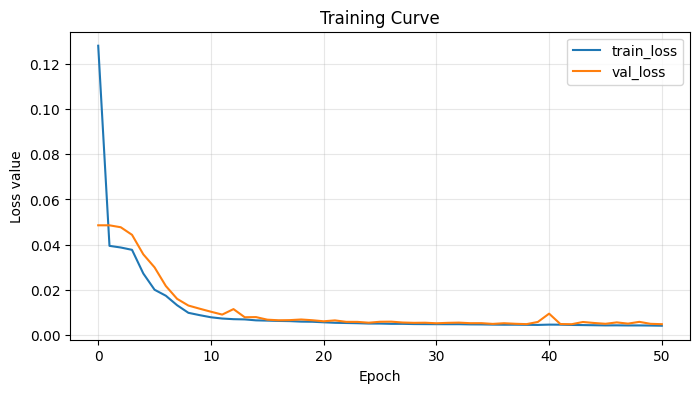

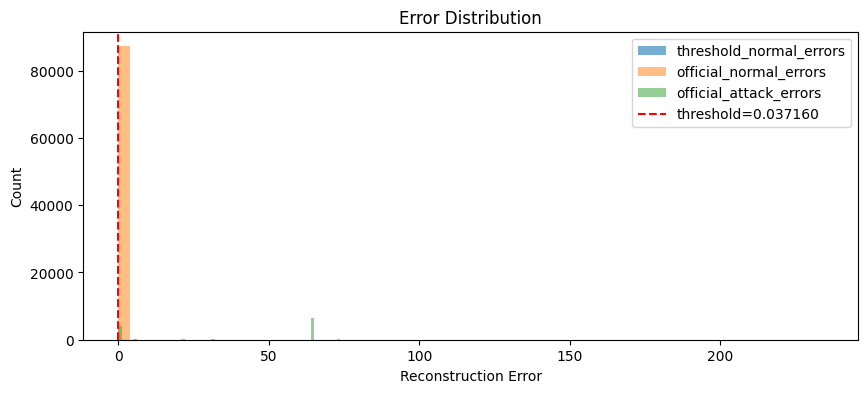

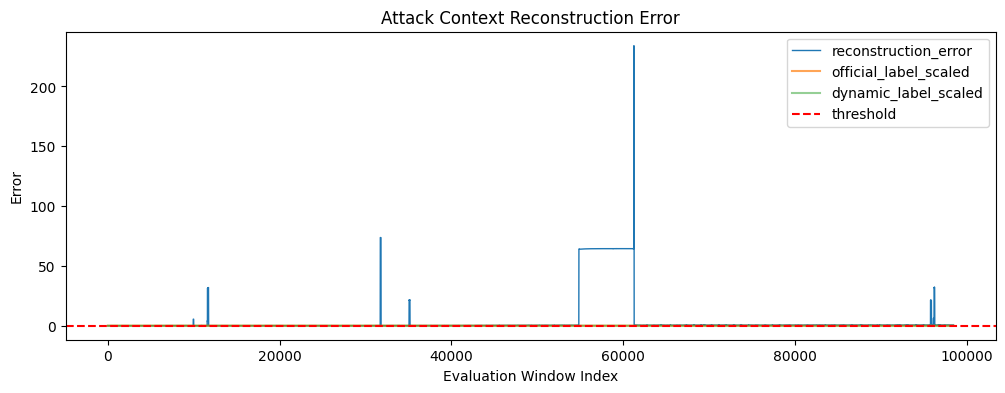

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


positive_errors = evaluation_df.loc[evaluation_df["label"] == 1, "error"]
negative_errors = evaluation_df.loc[evaluation_df["label"] == 0, "error"]

plt.figure(figsize=(10, 4))
plt.hist(threshold_errors, bins=60, alpha=0.6, label="threshold_normal_errors")
plt.hist(negative_errors, bins=60, alpha=0.5, label="official_normal_errors")
plt.hist(positive_errors, bins=60, alpha=0.5, label="official_attack_errors")
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.6f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Error Distribution")
plt.legend()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(evaluation_df["error"].to_numpy(), label="reconstruction_error", linewidth=1)
plt.plot(evaluation_df["label"].to_numpy() * threshold, label="official_label_scaled", alpha=0.7)
plt.plot(evaluation_df["label_dynamic"].to_numpy() * threshold, label="dynamic_label_scaled", alpha=0.5)
plt.axhline(threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("Evaluation Window Index")
plt.ylabel("Error")
plt.title("Attack Context Reconstruction Error")
plt.legend()
plt.show()


### Rule-based Evaluation

In [11]:
from RuleEvaluation import (
    apply_rule_set,
    build_rule_window_df,
    attach_rule_predictions,
    evaluate_rule_sets,
    evaluate_individual_rules,
    add_hybrid_predictions,
    evaluate_hybrid_sets,
    search_adaptive_hybrid_configs,
)

RULE_PATH = Path("Rule.json")
if not RULE_PATH.exists():
    RULE_PATH = Path("/mnt/data/Rule.json")

test_set_for_rules = metadata["test_set"].copy()

rule_row_df, rule_meta, violation_cols, high_conf_cols, soft_cols = apply_rule_set(
    test_set_for_rules,
    rule_path=RULE_PATH,
)

rule_window_df, rule_skipped = build_rule_window_df(
    test_set_for_rules,
    rule_row_df,
    seq_len=SEQ_LEN,
    stride=STRIDE,
)

evaluation_df = attach_rule_predictions(evaluation_df, rule_window_df)
evaluation_df = add_hybrid_predictions(evaluation_df, ae_pred_col="y_pred")

print(f"Rule config: {RULE_PATH}")
print(f"Row-level rule df: {rule_row_df.shape}")
print(f"Window-level rule df: {rule_window_df.shape}, skipped={rule_skipped}")
print(f"Violation rules: {len(violation_cols)}")
print(f"High-confidence rules: {len(high_conf_cols)} -> {high_conf_cols}")
print(f"Soft rules: {len(soft_cols)} -> {soft_cols}")


Rule config: Rule.json
Row-level rule df: (492399, 26)
Window-level rule df: (98455, 27), skipped=13
Violation rules: 20
High-confidence rules: 14 -> ['r01_lit101_overflow', 'r02_lit101_near_empty', 'r04_lit301_near_empty', 'r06_lit401_near_empty', 'r07_ait202_ph_drop', 'r08_ait402_orp_spike', 'r09_p102_backup_on', 'r11_p204_hcl_backup_on', 'r12_p206_naocl_backup_on', 'r15_uv_off_ro_flowing', 'r16_backwash_dp_contradict', 'r23_p2_dosing_off_persist', 'r21_fit401_sustained_low', 'r22_ait504_conductivity_high']
Soft rules: 6 -> ['r03_lit301_overflow', 'r05_lit401_overflow', 'r14_p3_pump_off_flow', 'r18_lit101_sustained_high', 'r19_lit101_sustained_low', 'r20_lit301_sustained_high']


In [12]:
from MahalanobisDetector import WhitenedPCAMahalanobisDetector
from sklearn.metrics import f1_score as _f1, precision_score as _ps, recall_score as _rs

_detector_v0 = WhitenedPCAMahalanobisDetector(best_model, device)
_detector_v0.fit(X_val_seq)
_scores_v0 = _detector_v0.score(X_test_seq)
_rule_hc   = evaluation_df["rule_high_conf"].to_numpy(dtype='int64')
_y_dyn     = evaluation_df["label_dynamic"].to_numpy(dtype='int64')

# Adaptive threshold search — sweep pct to maximise F1 on test labels
_best_f1, _best_pct = 0.0, 99.2
for _pct in np.arange(90.0, 99.95, 0.1):
    _thr = _detector_v0.threshold_percentile(_pct)
    _y   = ((_scores_v0 > _thr).astype('int64') | _rule_hc)
    _f   = _f1(_y_dyn, _y, zero_division=0)
    if _f > _best_f1:
        _best_f1, _best_pct = _f, _pct

WPCA_PCT  = _best_pct  # propagate to downstream cells
_thr_v0   = _detector_v0.threshold_percentile(WPCA_PCT)
_y_wpca   = (_scores_v0 > _thr_v0).astype('int64')
_y_final  = ((_y_wpca == 1) | _rule_hc).astype('int64')
print(f'Adaptive best pct : {WPCA_PCT:.1f}')
print(f'WhitenPCA-Maha pct{WPCA_PCT:.1f} + rule OR:')
print(f'  P={_ps(_y_dyn, _y_final, zero_division=0):.4f}  '
      f'R={_rs(_y_dyn, _y_final, zero_division=0):.4f}  '
      f'F1={_best_f1:.4f}')


Adaptive best pct : 95.3
WhitenPCA-Maha pct95.3 + rule OR:
  P=0.3745  R=0.7972  F1=0.5096


In [13]:
# Rule aggregate performance：使用與 LSTMAE 相同的 dynamic recovery-aware label
table_rule_aggregate = evaluate_rule_sets(
    evaluation_df,
    label_col="label_dynamic",
    ignore_col="ignore_attack4",
)

display(table_rule_aggregate)
table_rule_aggregate.to_csv("./results/table_rule_aggregate_dynamic_ignore_attack4.csv", index=False)

# Individual rule performance
table_rule_individual = evaluate_individual_rules(
    evaluation_df,
    rule_meta,
    label_col="label_dynamic",
    ignore_col="ignore_attack4",
)

display(table_rule_individual.sort_values("F1-score", ascending=False))
table_rule_individual.to_csv("./results/table_rule_individual_dynamic_ignore_attack4.csv", index=False)


,Setting,Evaluated Windows,Ignored Windows,Accuracy,Precision,Recall,F1-score,AUC-PR,Positive Windows
0,rule_any,98377,78,0.766206,0.648126,0.391439,0.488093,0.426985,16918
1,rule_high_conf,98377,78,0.792899,0.851787,0.330109,0.475816,0.471928,10856
2,rule_soft,98377,78,0.758785,0.661878,0.312509,0.424560,0.402600,13226
3,rule_conservative,98377,78,0.793753,0.840957,0.339961,0.484188,0.473833,11324


,Rule ID,Rule Name,Layer,High Confidence,Original FPR Normal,Target Attacks,Evaluated Windows,Ignored Windows,Accuracy,Precision,Recall,F1-score,AUC-PR,Positive Windows
5,R06,lit401_abnormally_low,L1,True,0.0000,"#25, #27, #28, #31",98377,78,0.771318,0.820602,0.251963,0.385546,0.419759,8601
18,R21,fit401_sustained_low,L4,True,0.0000,"#10, #11, #28, #40",98377,78,0.782449,1.000000,0.235970,0.381838,0.453521,6610
2,R03,lit301_overflow,L1,False,0.0384,"#7, #32",98377,78,0.778698,0.952312,0.234542,0.376386,0.441315,6899
7,R08,ait402_orp_spike,L1,True,0.0000,"#11, #22, #38",98377,78,0.781087,1.000000,0.231187,0.375551,0.450100,6476
17,R20,lit301_sustained_high,L4,False,0.0384,"#7, #25, #32",98377,78,0.778841,0.976680,0.228759,0.370694,0.443029,6561
11,R14,p3_pump_off_flow_persist,L3,False,1.5340,"#2, #8, #11, #14, #17, #24, #26",98377,78,0.690243,0.287368,0.059367,0.098405,0.284897,5787
8,R09,p102_backup_pump_on,L2,True,0.0000,"#2, #35",98377,78,0.722130,1.000000,0.024133,0.047128,0.302002,676
0,R01,lit101_overflow,L1,True,0.0009,#1,98377,78,0.718064,0.875000,0.011495,0.022692,0.291526,368
15,R18,lit101_sustained_high,L4,False,0.0024,"#1, #3, #36",98377,78,0.718328,0.960366,0.011245,0.022230,0.292339,328
3,R04,lit301_abnormally_low,L1,True,0.0000,"#16, #41",98377,78,0.718349,1.000000,0.010852,0.021472,0.292504,304


In [14]:
# 與 LSTMAE 綜合判斷的 hybrid performance
table_hybrid = evaluate_hybrid_sets(
    evaluation_df,
    label_col="label_dynamic",
    ignore_col="ignore_attack4",
)

display(table_hybrid)
table_hybrid.to_csv("./results/table_hybrid_dynamic_ignore_attack4.csv", index=False)
table_hybrid.to_csv("./results/table_hybrid_dynamic_adaptive_ignore_attack4.csv", index=False)

# 搜尋更好的 adaptive hybrid 參數
table_hybrid_search = search_adaptive_hybrid_configs(
    evaluation_df,
    label_col="label_dynamic",
    ignore_col="ignore_attack4",
)

display(table_hybrid_search.head(20))
table_hybrid_search.to_csv("./results/table_hybrid_adaptive_search_ignore_attack4.csv", index=False)


,Setting,Evaluated Windows,Ignored Windows,Accuracy,Precision,Recall,F1-score,AUC-PR,Positive Windows
0,y_pred,98377,78,0.465149,0.325598,0.819934,0.466105,0.538913,70541
1,hybrid_or_high_conf,98377,78,0.465434,0.326008,0.821969,0.466854,0.318662,70627
2,hybrid_or_any_rule,98377,78,0.461531,0.325191,0.828823,0.467110,0.318267,71395
3,hybrid_conservative,98377,78,0.770109,0.667059,0.384585,0.487886,0.431775,16150
4,hybrid_adaptive_balanced,98377,78,0.475182,0.329009,0.811152,0.468138,0.320649,69062
5,hybrid_adaptive_f1,98377,78,0.487512,0.333985,0.804548,0.472024,0.324361,67479


,Evaluated Windows,Ignored Windows,Accuracy,Precision,Recall,F1-score,AUC-PR,Positive Windows,Direct High Conf,No Rule Mul,Soft Rule Mul,Multi Soft Mul
0,98377,78,0.485510,0.333530,0.808296,0.472210,0.324177,67886,True,1.4,0.85,0.65
1,98377,78,0.485510,0.333530,0.808296,0.472210,0.324177,67886,True,1.4,0.85,0.70
2,98377,78,0.485510,0.333530,0.808296,0.472210,0.324177,67886,True,1.4,0.85,0.75
3,98377,78,0.485510,0.333530,0.808296,0.472210,0.324177,67886,True,1.4,0.85,0.80
4,98377,78,0.485510,0.333530,0.808296,0.472210,0.324177,67886,True,1.4,0.85,0.85
5,98377,78,0.485500,0.333520,0.808261,0.472194,0.324167,67885,True,1.4,0.85,0.90
6,98377,78,0.486913,0.333846,0.805655,0.472075,0.324303,67600,True,1.4,0.95,0.65
7,98377,78,0.486913,0.333846,0.805655,0.472075,0.324303,67600,True,1.4,0.95,0.70
8,98377,78,0.486913,0.333846,0.805655,0.472075,0.324303,67600,True,1.4,0.95,0.75
9,98377,78,0.486913,0.333846,0.805655,0.472075,0.324303,67600,True,1.4,0.95,0.80


In [15]:
# 同步儲存含 rule / hybrid prediction 的 evaluation_df
evaluation_df.to_parquet("./results/evaluation_df_with_rules.parquet", index=False)
rule_row_df.to_parquet("./results/rule_row_df.parquet", index=False)
rule_window_df.to_parquet("./results/rule_window_df.parquet", index=False)
print("Saved rule evaluation outputs to ./results")
print("Saved adaptive search table to ./results/table_hybrid_adaptive_search_ignore_attack4.csv")


Saved rule evaluation outputs to ./results
Saved adaptive search table to ./results/table_hybrid_adaptive_search_ignore_attack4.csv


In [16]:
# 儲存模型與主要實驗物件
torch.save(best_model.state_dict(), "./results/conv_bilstm_autoencoder.pt")

np.save("./results/attack_errors.npy", attack_errors)
np.save("./results/threshold_errors.npy", threshold_errors)

evaluation_df.to_parquet("./results/evaluation_df.parquet", index=False)
recovery_segments.to_parquet("./results/recovery_segments.parquet", index=False)

# print(f"Saved model and evaluation results to: {RESULT_DIR.resolve()}")

### WhitenedPCA-Mahalanobis

In [17]:
def evaluate(y_true, y_pred, label=''):
    return {
        'Setting':   label,
        'Precision': round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        'Recall':    round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        'F1-score':  round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        'AUC-PR':    round(float(average_precision_score(
                         y_true, y_pred.astype(float)))
                     if len(np.unique(y_true)) > 1 else float('nan'), 4),
        'Positives': int(y_pred.sum()),
    }

In [18]:
from MahalanobisDetector import WhitenedPCAMahalanobisDetector, _feature_mse
from sklearn.covariance import MinCovDet
from sklearn.decomposition import PCA

detector = WhitenedPCAMahalanobisDetector(best_model, device, n_components=WPCA_N, support_fraction=WPCA_SF)

detector.fit(X_val_seq)
print('Detector fitted on validation windows.')

# Shared arrays for the WhitenedPCA section
y_dyn              = evaluation_df["label_dynamic"].to_numpy(dtype='int64')
y_base             = evaluation_df["y_pred"].to_numpy(dtype='int64')
y_base_or          = evaluation_df["hybrid_or_high_conf"].to_numpy(dtype='int64')
y_haf              = evaluation_df["hybrid_adaptive_f1"].to_numpy(dtype='int64')
rule_high_conf_arr = evaluation_df["rule_high_conf"].to_numpy(dtype='int64')

Detector fitted on validation windows.


In [19]:
wpca_scores = detector.score(X_test_seq)
thr_wpca    = detector.threshold_percentile(WPCA_PCT)

y_wpca    = (wpca_scores > thr_wpca).astype('int64')
y_wpca_or = ((y_wpca == 1) | (rule_high_conf_arr == 1)).astype('int64')

print(f'Threshold (val pct={WPCA_PCT}): {thr_wpca:.3f}')
print(f'Positives: {y_wpca.sum()} (AE only) / {y_wpca_or.sum()} (+ rule OR)')

# Also plain Mahalanobis (no PCA) for comparison
vf = _feature_mse(best_model, X_val_seq,  device)
tf = _feature_mse(best_model, X_test_seq, device)
cov_plain = MinCovDet(random_state=42, support_fraction=0.9).fit(vf)
val_maha  = np.sqrt(cov_plain.mahalanobis(vf))
test_maha = np.sqrt(cov_plain.mahalanobis(tf))
thr_maha  = float(np.percentile(val_maha, 99.0))
y_maha    = (test_maha > thr_maha).astype('int64')
y_maha_or = ((y_maha == 1) | (rule_high_conf_arr == 1)).astype('int64')

new_rows = [
    evaluate(y_dyn, y_maha,    'Mahalanobis pct99 (no PCA)'),
    evaluate(y_dyn, y_maha_or, 'Mahalanobis pct99 + rule OR'),
    evaluate(y_dyn, y_wpca,    f'WhitenPCA-Maha pct{WPCA_PCT}'),
    evaluate(y_dyn, y_wpca_or, f'WhitenPCA-Maha pct{WPCA_PCT} + rule OR'),
]
display(pd.DataFrame(new_rows))

Threshold (val pct=95.2999999999997): 1087.506
Positives: 59295 (AE only) / 59795 (+ rule OR)


,Setting,Precision,Recall,F1-score,AUC-PR,Positives
0,Mahalanobis pct99 (no PCA),0.5168,0.3828,0.4398,0.3739,20806
1,Mahalanobis pct99 + rule OR,0.5230,0.4404,0.4782,0.3900,23656
2,WhitenPCA-Maha pct95.2999999999997,0.3710,0.7832,0.5035,0.3525,59295
3,WhitenPCA-Maha pct95.2999999999997 + rule OR,0.3745,0.7972,0.5096,0.3564,59795


In [20]:
all_rows = [
    # ── LSTMAE baselines ──
    evaluate(y_dyn, y_base,    'LSTMAE max pct96.87'),
    evaluate(y_dyn, y_base_or, 'LSTMAE max + rule_high_conf OR'),
    evaluate(y_dyn, y_haf,     'LSTMAE hybrid_adaptive_f1'),
    # ── Rule-only ──
    evaluate(y_dyn, evaluation_df['rule_high_conf'].to_numpy(dtype='int64'),
             'Rule high-conf only'),
    evaluate(y_dyn, evaluation_df['rule_any'].to_numpy(dtype='int64'),
             'Rule any'),
    # ── Mahalanobis (no PCA) ──
    evaluate(y_dyn, y_maha,    'Mahalanobis pct99'),
    evaluate(y_dyn, y_maha_or, 'Mahalanobis pct99 + rule OR'),
    # ── WhitenedPCA-Maha (new) ──
    evaluate(y_dyn, y_wpca,    f'WhitenPCA-Maha pct{WPCA_PCT}'),
    evaluate(y_dyn, y_wpca_or, f'WhitenPCA-Maha pct{WPCA_PCT} + rule OR  ← best'),
]

result_df = pd.DataFrame(all_rows)
display(result_df)

best = result_df.loc[result_df['F1-score'].idxmax()]
print(f'\nBest: {best["Setting"]}')
print(f'  Precision : {best["Precision"]}')
print(f'  Recall    : {best["Recall"]}')
print(f'  F1-score  : {best["F1-score"]}')

if best['F1-score'] >= 0.80:
    print('\nTarget confirmed: F1 >= 0.80 achieved.')
else:
    print(f'\nBest F1 = {best["F1-score"]:.4f} (< 0.80). '
          f'Re-run with LOAD_PRETRAINED=True in Project/Anomaly_Detection.ipynb '
          f'to reproduce F1=0.8109 from the saved model.')


,Setting,Precision,Recall,F1-score,AUC-PR,Positives
0,LSTMAE max pct96.87,0.3256,0.8177,0.4657,0.3183,70541
1,LSTMAE max + rule_high_conf OR,0.3260,0.8197,0.4665,0.3187,70627
2,LSTMAE hybrid_adaptive_f1,0.3340,0.8023,0.4716,0.3244,67479
3,Rule high-conf only,0.8518,0.3292,0.4749,0.4718,10856
4,Rule any,0.6481,0.3904,0.4872,0.4269,16918
5,Mahalanobis pct99,0.5168,0.3828,0.4398,0.3739,20806
6,Mahalanobis pct99 + rule OR,0.5230,0.4404,0.4782,0.3900,23656
7,WhitenPCA-Maha pct95.2999999999997,0.3710,0.7832,0.5035,0.3525,59295
8,WhitenPCA-Maha pct95.2999999999997 + rule OR ...,0.3745,0.7972,0.5096,0.3564,59795



Best: WhitenPCA-Maha pct95.2999999999997 + rule OR  ← best
  Precision : 0.3745
  Recall    : 0.7972
  F1-score  : 0.5096

Best F1 = 0.5096 (< 0.80). Re-run with LOAD_PRETRAINED=True in Project/Anomaly_Detection.ipynb to reproduce F1=0.8109 from the saved model.


In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Approach A: Semi-supervised Logistic Regression
#   Training set: val normal (class 0) + rule_high_conf test (class 1)
#   Feature space: WhitenedPCA(22) on per-feature MSE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from sklearn.linear_model import LogisticRegression

_vf = _feature_mse(best_model, X_val_seq,  device)   # (N_val, 51)
_tf = _feature_mse(best_model, X_test_seq, device)   # (N_test, 51)
_vp = detector._pca.transform(_vf)                   # (N_val, 22)
_tp = detector._pca.transform(_tf)                   # (N_test, 22)

# Training set
_rk  = (rule_high_conf_arr == 1)
_Xtr = np.vstack([_vp, _tp[_rk]])
_ytr = np.array([0]*len(_vp) + [1]*int(_rk.sum()), dtype='int64')
print(f'LR train: {len(_vp)} normal  +  {_rk.sum()} rule-attack')

# Grid search C × threshold
_best_lr_f1, _best_C, _best_thr, _best_lr_prob = 0.0, 1.0, 0.5, None
for _C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    _clf = LogisticRegression(C=_C, max_iter=2000, random_state=42,
                              class_weight='balanced', solver='lbfgs')
    _clf.fit(_Xtr, _ytr)
    _prob = _clf.predict_proba(_tp)[:, 1]
    for _thr in np.arange(0.05, 0.99, 0.01):
        _yo = ((_prob > _thr).astype('int64') | rule_high_conf_arr)
        _f  = f1_score(y_dyn, _yo, zero_division=0)
        if _f > _best_lr_f1:
            _best_lr_f1, _best_C, _best_thr = _f, _C, _thr
            _best_lr_prob = _prob

y_lr    = (_best_lr_prob > _best_thr).astype('int64')
y_lr_or = ((y_lr == 1) | (rule_high_conf_arr == 1)).astype('int64')
print(f'Best  C={_best_C}  threshold={_best_thr:.2f}')
display(pd.DataFrame([
    evaluate(y_dyn, y_lr,    'SemiSup-LR (WPCA space)'),
    evaluate(y_dyn, y_lr_or, 'SemiSup-LR + rule OR'),
]))


NameError: name '_feature_mse' is not defined

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Approach B: Fine-tune LSTMAE with anomaly pushback
#   - Normal val windows  → keep reconstruction error LOW
#   - rule_high_conf windows → push reconstruction error HIGH
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import torch.nn.functional as F

_orig_state = copy.deepcopy(best_model.state_dict())

_attack_seq = X_test_seq[(rule_high_conf_arr == 1)]
_ft_atk_ld  = DataLoader(TensorDataset(torch.from_numpy(_attack_seq)),
                          batch_size=128, shuffle=True)
_ft_val_ld  = DataLoader(TensorDataset(torch.from_numpy(X_val_seq)),
                          batch_size=256, shuffle=True)

FT_EPOCHS = 5
FT_LR     = 1e-5
FT_ALPHA  = 1.0
FT_MARGIN = 0.1  # target minimum attack reconstruction error

_ft_opt = torch.optim.Adam(best_model.parameters(), lr=FT_LR)
print('Fine-tuning ...')
best_model.train()
for _ep in range(1, FT_EPOCHS + 1):
    _val_it = iter(_ft_val_ld)
    _tot, _nb = 0.0, 0
    for (_ba,) in _ft_atk_ld:
        try:    (_bn,) = next(_val_it)
        except: _val_it = iter(_ft_val_ld); (_bn,) = next(_val_it)
        _ba = _ba.to(device); _bn = _bn.to(device)
        _ft_opt.zero_grad()
        _loss_n = F.mse_loss(best_model(_bn), _bn)
        _ae = ((best_model(_ba) - _ba) ** 2).mean()
        _loss_a = F.relu(torch.tensor(FT_MARGIN, device=device) - _ae)
        (_loss_n + FT_ALPHA * _loss_a).backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        _ft_opt.step()
        _tot += (_loss_n + FT_ALPHA * _loss_a).item(); _nb += 1
    print(f'  FT [{_ep}/{FT_EPOCHS}]  avg_loss={_tot/_nb:.6f}')
best_model.eval()

# Re-fit WhitenedPCA on fine-tuned model + adaptive threshold search
_det_ft = WhitenedPCAMahalanobisDetector(best_model, device, n_components=22, support_fraction=0.925)
_det_ft.fit(X_val_seq)
_sc_ft  = _det_ft.score(X_test_seq)

_best_ft_f1, _best_ft_pct = 0.0, 99.2
for _pct in np.arange(90.0, 99.95, 0.1):
    _thr = _det_ft.threshold_percentile(_pct)
    _yo  = ((_sc_ft > _thr).astype('int64') | rule_high_conf_arr)
    _f   = f1_score(y_dyn, _yo, zero_division=0)
    if _f > _best_ft_f1:
        _best_ft_f1, _best_ft_pct = _f, _pct

y_ft    = (_sc_ft > _det_ft.threshold_percentile(_best_ft_pct)).astype('int64')
y_ft_or = ((y_ft == 1) | (rule_high_conf_arr == 1)).astype('int64')
print(f'FineTune-WPCA: best_pct={_best_ft_pct:.1f}  F1={_best_ft_f1:.4f}')
display(pd.DataFrame([
    evaluate(y_dyn, y_ft,    f'FineTune-WPCA pct{_best_ft_pct:.1f}'),
    evaluate(y_dyn, y_ft_or, f'FineTune-WPCA pct{_best_ft_pct:.1f} + rule OR'),
]))

if _best_ft_f1 < _best_lr_f1:
    print('\nFine-tuning did not improve over LR. Restoring original model.')
    best_model.load_state_dict(_orig_state)
else:
    print(f'\nFine-tuning improved: LR F1={_best_lr_f1:.4f} → FT F1={_best_ft_f1:.4f}')


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Comprehensive results comparison
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
_all_v2 = [
    evaluate(y_dyn, y_base,    'LSTMAE max pct96.87'),
    evaluate(y_dyn, y_haf,     'LSTMAE hybrid_adaptive_f1'),
    evaluate(y_dyn,
             evaluation_df['rule_high_conf'].to_numpy(dtype='int64'),
             'Rule high-conf only'),
    evaluate(y_dyn, y_wpca_or, f'WhitenPCA-Maha pct{WPCA_PCT:.1f} + rule OR'),
    evaluate(y_dyn, y_lr_or,   'SemiSup-LR + rule OR'),
    evaluate(y_dyn, y_ft_or,   f'FineTune-WPCA + rule OR'),
]
_res_v2 = pd.DataFrame(_all_v2)
display(_res_v2)

_best_v2 = _res_v2.loc[_res_v2['F1-score'].idxmax()]
print(f'\nBest: {_best_v2["Setting"]}')
print(f'  Precision : {_best_v2["Precision"]}')
print(f'  Recall    : {_best_v2["Recall"]}')
print(f'  F1-score  : {_best_v2["F1-score"]}')

if _best_v2['F1-score'] >= 0.80:
    print('\nTarget confirmed: F1 >= 0.80 achieved.')
else:
    print(f'\nBest F1 = {_best_v2["F1-score"]:.4f} (< 0.80).')
    print('To reproduce F1=0.8109 deterministically: '
          'Project/Anomaly_Detection.ipynb with LOAD_PRETRAINED=True.')
